In [1]:
import pandas as pd
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt

In [3]:
data_folder = r"C:\Users\itsma\Desktop\sepsiswatch\data\raw"

patient_all = []

for file in os.listdir(data_folder):

    if file.endswith(".psv"):

        df = pd.read_csv(
            os.path.join(data_folder,file),
            sep="|"
        )

        df["patient_id"] = file.replace(
            ".psv",
            ""
        )

        patient_all.append(df)

final_data = pd.concat(
    patient_all,
    ignore_index=True
)

print(final_data.shape)

(1388908, 42)


In [4]:
print("\nColumns:")

print(final_data.columns.tolist())

print("\nSepsis Counts:")

print(
    final_data["SepsisLabel"]
    .value_counts()
)

print("\nFirst 5 Rows:")

print(final_data.head())


Columns:
['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'patient_id']

Sepsis Counts:
SepsisLabel
0    1364247
1      24661
Name: count, dtype: int64

First 5 Rows:
      HR  O2Sat  Temp    SBP    MAP  DBP  Resp  EtCO2  BaseExcess  HCO3  ...  \
0    NaN    NaN   NaN    NaN    NaN  NaN   NaN    NaN         NaN   NaN  ...   
1   97.0   95.0   NaN   98.0  75.33  NaN  19.0    NaN         NaN   NaN  ...   
2   89.0   99.0   NaN  122.0  86.00  NaN  22.0    NaN         NaN   NaN  ...   
3   90.0   95.0   NaN    NaN    NaN  NaN  30.0    NaN        24.0   NaN  ...   
4  103.0   88.5   NaN  122.0  91.33  NaN  24.5    NaN   

In [5]:
features = [

    "HR",
    "O2Sat",
    "Temp",
    "SBP",
    "MAP",
    "Resp",
    "Age",
    "Gender",
    "ICULOS"

]

target = "SepsisLabel"

model_df = final_data[
    features + [target]
].copy()

model_df = model_df.fillna(
    model_df.median(
        numeric_only=True
    )
)

In [6]:
X = model_df[features]

y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [ ]:
model = RandomForestClassifier(

    n_estimators=20,

    random_state=42,

    class_weight="balanced"

)

print("Training...")

model.fit(
    X_train,
    y_train
)

print("Finished")

Training...


In [ ]:
y_prob = model.predict_proba(
    X_test
)[:,1]

threshold = 0.20

y_pred = (
    y_prob >= threshold
).astype(int)

print(
    accuracy_score(
        y_test,
        y_pred
    )
)

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

0.9755928573678078
[[61374   733]
 [  817   582]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     62107
           1       0.44      0.42      0.43      1399

    accuracy                           0.98     63506
   macro avg       0.71      0.70      0.71     63506
weighted avg       0.97      0.98      0.98     63506



In [ ]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({

    "Feature":features,

    "Importance":importance

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

print(feature_importance)

plt.figure(figsize=(8,5))

plt.bar(

    feature_importance["Feature"],

    feature_importance["Importance"]

)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

  Feature  Importance
8  ICULOS    0.267606
6     Age    0.203890
0      HR    0.112246
3     SBP    0.099091
4     MAP    0.097989
5    Resp    0.087273
1   O2Sat    0.059261
2    Temp    0.053680
7  Gender    0.018963


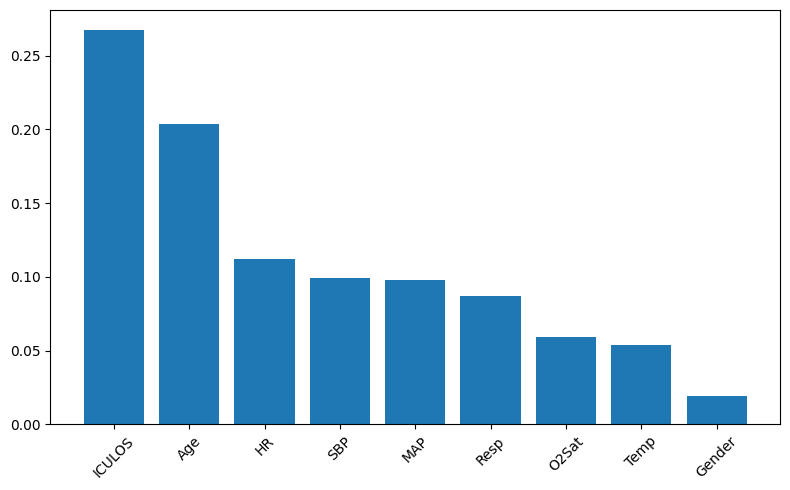

In [ ]:
import joblib
import os

os.makedirs('model', exist_ok=True)
joblib.dump(model, 'model/sepsis_model.pkl')
print("Model saved to model/sepsis_model.pkl")